# Лабораторная работа 2. Просодика

Юдин Артём М4221

Предсказание мест и длительности пауз по тексту корпуса RUSLAN.

Порог на тестовой выборке: F1 места паузы не ниже 0.7, MAE меньше 0.12 с.

# 1. Подготовка текста и разметки

Словесная разметка — общая для группы MFA-разметка `data/RUSLAN_align_v2` (русский MFA 3.1), построенная по сырому тексту. Нормализованный текст взят из первой работы.

Слова при этом не переписываются: расшифровки аббревиатур из первой работы не совпадают со словарём MFA, и такие фразы скрипт подготовки отбрасывает. Последняя пауза фразы в метрики не входит: она попадает на стык аудиофайлов.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from praatio import textgrid
from sklearn.metrics import f1_score, mean_absolute_error, precision_score, recall_score

from pause_predictor import PausePredictor, RulePausePredictor, calc_metrics, punct_class

pd.set_option("display.max_rows", 20)
plt.rcParams["figure.figsize"] = (7, 3.5)
plt.rcParams["axes.grid"] = True

pause_df = pd.read_csv("data/RUSLAN_pause_metadata.csv", sep="|", quoting=csv.QUOTE_NONE)
internal = pause_df[pause_df.is_last_word == 0].copy()
internal["punct"] = internal.label_raw.astype(str).map(punct_class)
print(f"Фраз после стыковки с TextGrid: {pause_df.id.nunique()}")
print(f"Слов: {len(pause_df)}, из них не последних: {len(internal)}")
print(pause_df["set"].value_counts().to_string())


Фраз после стыковки с TextGrid: 21004
Слов: 239957, из них не последних: 218953
set
train    191837
test      48120


# 2. Длительности

Длительность буквы - длительность слова MFA, делённая на число букв в метке TextGrid.
В среднюю паузу не включена пауза после последнего слова.

In [2]:
VOWELS = set("a e i o u æ ɐ ə ɛ ɨ ɪ ɵ ʉ ʊ".split())
ALIGN_DIR = Path("../../data/RUSLAN_align_v2")

letter_len = pause_df.label.astype(str).str.len().clip(lower=1)
letter_duration = pause_df.duration / letter_len
pauses = internal.loc[internal.is_pause_after == 1, "pause_duration"]

vowel_duration = []
phone_silence = []
for utt_id in pause_df.id.drop_duplicates():
    path = ALIGN_DIR / f"{utt_id}.TextGrid"
    grid = textgrid.openTextgrid(path, includeEmptyIntervals=True)
    _words, phones = grid.tiers
    for interval in phones.entries:
        duration = interval.end - interval.start
        if interval.label in VOWELS:
            vowel_duration.append(duration)
        elif interval.label in {"", "<SIL>", "sil", "sp"}:
            phone_silence.append(duration)

vowel_duration = np.asarray(vowel_duration)
summary = pd.Series(
    {
        "пауза, с": pauses.mean(),
        "слово, с": pause_df.duration.mean(),
        "буква, с": letter_duration.mean(),
        "гласная, с": vowel_duration.mean(),
    }
)
print(summary.round(4).to_string())
print(f"Медиана внутренней паузы: {pauses.median():.3f} с; доля короче 50 мс: {(pauses < 0.05).mean():.3f}")
print(f"Гласных интервалов: {len(vowel_duration)}")


пауза, с      0.1592
слово, с      0.4084
буква, с      0.0771
гласная, с    0.0561
Медиана внутренней паузы: 0.100 с; доля короче 50 мс: 0.315
Гласных интервалов: 568078


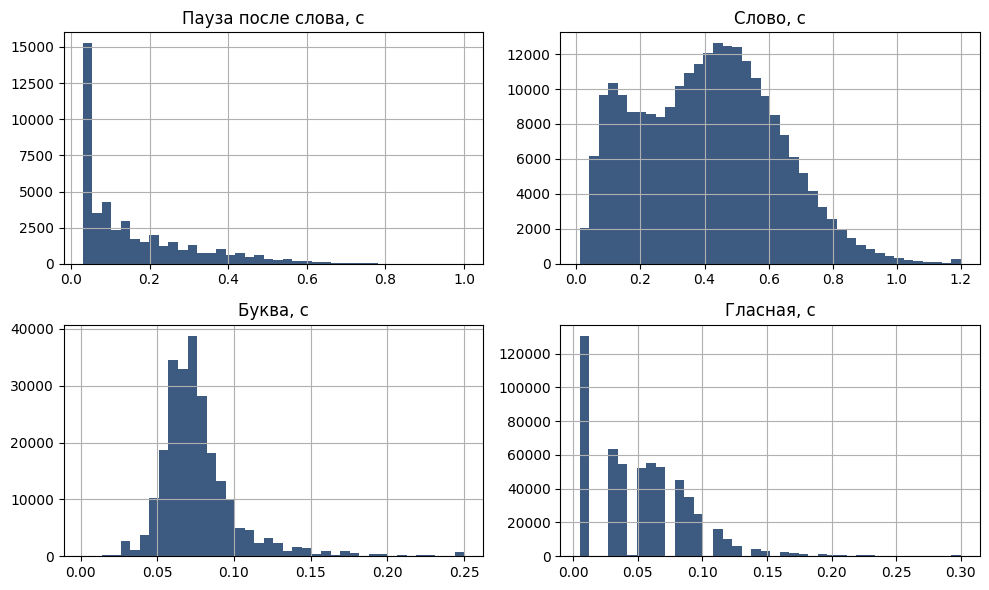

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
series = [
    (pauses.clip(upper=1.0), "Пауза после слова, с"),
    (pause_df.duration.clip(upper=1.2), "Слово, с"),
    (letter_duration.clip(upper=0.25), "Буква, с"),
    (pd.Series(vowel_duration).clip(upper=0.3), "Гласная, с"),
]
for axis, (values, title) in zip(axes, series, strict=True):
    axis.hist(values, bins=40, color="#3d5a80")
    axis.set_title(title)
fig.tight_layout()
plt.show()


У длительности паузы два слоя.
Узкий пик около 30–50 мс — нижняя полка выравнивателя MFA (в нашем скрипте предиктора - MIN_PAUSE).
Второй слой, примерно от 100 мс, — собственно паузы на границах логических фраз.
Медиана внутренней паузы 0.11 с, среднее - 0.17.

Слово в среднем длится около 0.40 с, буква — 0.076 с, гласная дольше, поскольку на них ставится ударение, из-за чего они протягиваются.

# 3. Положение пауз

In [4]:
by_punct = (
    internal.groupby("punct")
    .is_pause_after.agg(доля_пауз="mean", пауз="sum", токенов="count")
    .sort_values("пауз", ascending=False)
)
by_punct["доля_пауз"] = by_punct["доля_пауз"].round(3)
display(by_punct)

strong = internal.punct != "none"
print(
    "Доля внутренних пауз без знака препинания:",
    f"{(internal.loc[internal.is_pause_after == 1, 'punct'] == 'none').mean():.3f}",
)
print(
    "Правило «пауза после любого знака», весь корпус:",
    f"F1 {f1_score(internal.is_pause_after, strong.astype(int)):.3f}",
)


,доля_пауз,пауз,токенов
punct,,,
none,0.077,13500,174589
period,0.964,13178,13668
comma,0.549,9729,17730
dash,0.490,3398,6931
ellipsis,0.936,2503,2675
quest,0.880,1882,2139
excl,0.878,885,1008
q_excl,0.911,163,179
dot_q_excl,1.000,33,33


Доля внутренних пауз без знака препинания: 0.298
Правило «пауза после любого знака», весь корпус: F1 0.709


Точка, многоточие, вопрос, восклицание и сочетания `?!` / `.!?` почти всегда сопровождаются паузой.
Запятая и тире - только примерно в половине случаев: однородные члены и вводные конструкции дают знак без дыхания.
Около четверти внутренних пауз стоит после слова без знака.
Это смесь коротких смычек MFA и настоящих дыханий на границе клаузы, чаще перед союзом.
Поэтому одного правила по знакам недостаточно, но знак остаётся главным признаком.

# 4. Модель

`PausePredictor` обучается на словах обучающей подвыборки с `is_last_word == 0`.
На вход `predict` получает последовательность `label_raw`.

Признаки токена: класс завершающей пунктуации (отдельные классы у `?!`, `!?`, `.!?` и у тире), пунктуация соседей, часть речи текущего и соседних слов, относительная позиция, длины, флаги союза и заглавной буквы следующего слова, а также число слов и букв от предыдущего знака и до следующего.
Число слов и букв от предыдущего знака позволяет отличать короткую запятую в перечислении от запятой после длинного куска фразы.

Место паузы предсказывает `HistGradientBoostingClassifier` (поскольку он оказался самым точным из 3 моделей + модели расстановки пауз на основе правил).
Порог вероятности выбирается по F1 на отложенной валидационной подвыборке, которая была выделена из обучающей.
Длительность предсказывает `HistGradientBoostingRegressor` (аналогично классификатору) с функцией потерь absolute error, обученный только на словах, за которыми в разметке есть пауза.
Если классификатор паузу не поставил, длительность равна 0.

In [5]:
def score(frame: pd.DataFrame) -> dict[str, float]:
    """Precision, recall, F1 and MAE on true positives."""
    true_positive = (frame.is_pause_after == 1) & (frame.is_pause_hat == 1)
    return {
        "precision": precision_score(frame.is_pause_after, frame.is_pause_hat),
        "recall": recall_score(frame.is_pause_after, frame.is_pause_hat),
        "f1": f1_score(frame.is_pause_after, frame.is_pause_hat),
        "mae": mean_absolute_error(
            frame.loc[true_positive, "pause_duration"],
            frame.loc[true_positive, "pause_duration_hat"],
        ),
    }


predictor = PausePredictor()
predicted = []
for _, sentence in pause_df.groupby("id", sort=False):
    is_pause, duration = predictor.predict(sentence.label_raw.astype(str).tolist())
    block = sentence.copy()
    block["is_pause_hat"] = is_pause
    block["pause_duration_hat"] = duration
    predicted.append(block)
scored = pd.concat(predicted, ignore_index=True)
scored_internal = scored[scored.is_last_word == 0]

rows = []
for split in ("train", "test"):
    part = scored_internal[scored_internal["set"] == split]
    metrics = score(part)
    metrics["split"] = split
    metrics["model"] = "HistGradientBoosting"
    rows.append(metrics)
    print(split)
    calc_metrics(part)

rule = RulePausePredictor()
rule_rows = []
for _, sentence in pause_df.groupby("id", sort=False):
    is_pause, duration = rule.predict(sentence.label_raw.astype(str).tolist())
    block = sentence.copy()
    block["is_pause_hat"] = is_pause
    block["pause_duration_hat"] = duration
    rule_rows.append(block)

baseline = pd.concat(rule_rows, ignore_index=True)
baseline = baseline[baseline.is_last_word == 0]
for split in ("train", "test"):
    part = baseline[baseline["set"] == split]
    metrics = score(part)
    metrics["split"] = split
    metrics["model"] = "punctuation rule"
    rows.append(metrics)

report = pd.DataFrame(rows)[["model", "split", "precision", "recall", "f1", "mae"]]
display(report.round(4))

test_row = report[(report.model == "HistGradientBoosting") & (report.split == "test")].iloc[0]
assert test_row.f1 >= 0.7
assert test_row.mae < 0.12


Fitting hist_gradient_boosting


Validation F1: 0.7517626487675559
Pause threshold 0.370 on 175050 train tokens


train
PRC: 0.7967019883319443, REC: 0.7386984600099354, F1: 0.7666046111986252; MAE: 0.10334325908760938;
test
PRC: 0.7651157298063297, REC: 0.716862137641071, F1: 0.7402033588483948; MAE: 0.10852239941918487;


,model,split,precision,recall,f1,mae
0,HistGradientBoosting,train,0.7967,0.7387,0.7666,0.1033
1,HistGradientBoosting,test,0.7651,0.7169,0.7402,0.1085
2,punctuation rule,train,0.7178,0.7020,0.7098,0.1233
3,punctuation rule,test,0.7098,0.7010,0.7054,0.1218


На тестовой выборке градиентный бустинг даёт F1 около 0.74 и MAE около 0.109 с.
Правило по знакам препинания - F1 около 0.71 и MAE около 0.12 с.
Выигрыш позволяет преодолеть заданный порог по метрикам.
Около 30 мс разницы в MAE как раз отделяет среднюю по классу знака от регрессора, которому доступна длина фразы.

# Выводы

Мы обучили модель классификации пауз, которая определяет местонахождение этих пауз в тексте, а следом предсказывает длительность.
Протестировали несколько вариантов и ансамблевый метод на основе градиентного бустинга показал себя наиболее точным из представелнных.